In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

sns.set()

# Métodos de ensamble
## Modelos que votan
**Aprendizaje de Máquina - CEIA - FIUBA**

Los métodos de ensamble combinan varios modelos para obtener un rendimiento predictivo
mejor que el de cualquiera de ellos por separado. La idea es que, si los modelos se
equivocan en **lugares distintos**, al combinarlos los errores individuales se
compensan entre sí y el conjunto es más robusto que sus partes.

Esa frase esconde una condición que suele pasarse por alto: *"si se equivocan en
lugares distintos"*. Un ensamble de modelos que fallan siempre en los mismos casos no
aporta nada. Por eso, antes de ensamblar, vamos a **medir** cuán diversos son nuestros
modelos.

En esta notebook trabajamos con la familia de ensambles que combina modelos
**distintos entre sí** (*heterogéneos*), ya entrenados:

- **Voting** (duro y blando): los modelos votan y gana la mayoría.
- **Stacking**: en lugar de votar, un meta-modelo aprende cómo combinarlos.

En las notebooks 2 y 3 veremos la otra familia: ensambles de muchos modelos **del
mismo tipo** (bagging, random forest y boosting).

## El dataset: Pima Indians Diabetes

Usamos el dataset **Pima Indians Diabetes**, el mismo de las clases anteriores. Son datos médicos de 768 mujeres de la etnia Pima mayores de 21 años, y
el objetivo es predecir si desarrollan diabetes (`diabetes = 1`) o no.

Elegimos este dataset justamente porque **ya tenemos cuatro modelos entrenados sobre
él**, cada uno de una familia distinta y todos con el mismo split. Son los ingredientes
perfectos para un ensamble heterogéneo: no hay que entrenar nada nuevo, sólo combinar
lo que ya tenemos.

In [2]:
# Cargamos el dataset
df_pima = pd.read_csv("datasets/pima_diabetes.csv")

X = df_pima.drop(columns='diabetes')
y = df_pima['diabetes']

df_pima.head()

,embarazos,glucosa,presion_arterial,grosor_piel,insulina,imc,funcion_pedigri,edad,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Usamos el **mismo split** de las clases anteriores (`test_size=0.25`,
`random_state=0`, estratificado), para que todo lo que midamos sea comparable con lo
que ya veníamos haciendo.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
    random_state=0, stratify=y)

print(f"Entrenamiento: {X_train.shape[0]} muestras | Testeo: {X_test.shape[0]}")

Entrenamiento: 576 muestras | Testeo: 192


---
## Los modelos base

Estos son los cuatro modelos que fuimos construyendo a lo largo, con los
hiper-parámetros que encontramos en cada clase. Los definimos explícitamente acá para
tenerlos a la vista:

| Modelo | Clase | Hiper-parámetros |
|---|---|---|
| k-NN | 2 | `n_neighbors=3`, `weights='uniform'`, `p≈3.76` (Optuna) |
| Regresión Logística | 2 | `C=1`, `class_weight='balanced'` |
| SVC | 3 | kernel lineal, `C=1`, `class_weight='balanced'` (GridSearch) |
| Árbol de clasificación | 4 | `max_depth=4`, `min_samples_leaf=13`, `balanced` (Optuna) |

Los tres primeros necesitan **escalado**, así que los envolvemos en un `Pipeline` con
`StandardScaler`.

> **Ojo con el escalado dentro del ensamble.** Si escaláramos `X_train` "a mano" antes
> de armar el ensamble, el escalado se calcularía usando *todo* el train, incluyendo
> los folds de validación de la validación cruzada interna del stacking. Metiéndolo en
> un `Pipeline`, cada fold escala con sus propios datos y evitamos esa fuga.

In [4]:
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=3, weights='uniform',
                                   p=3.758948544078171))
])

logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1, class_weight='balanced',
                                 solver='liblinear', max_iter=5000))
])

# probability=True para que el SVC pueda participar del soft voting
svc = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(C=1, kernel='linear', class_weight='balanced',
                  probability=True, random_state=42))
])

tree = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_split=16,
                              min_samples_leaf=13, class_weight='balanced',
                              random_state=42)

estimators = [('logreg', logreg), ('knn', knn), ('svc', svc), ('tree', tree)]

Como las clases están desbalanceadas (65% / 35%), seguimos usando el
**F1-score** como métrica principal.

Armamos una función de evaluación para no repetir código. Devuelve las métricas de
testeo y, además, el **F1 por validación cruzada sobre el entrenamiento**: vamos a
necesitar los dos números, y más adelante veremos por qué.

In [5]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluar(nombre, modelo, umbral=None, f1_cv=None):
    """Entrena el modelo, lo evalúa en test y estima su F1 por CV en train.

    Con `umbral=None` se usa el `predict()` del modelo (umbral por defecto).
    Si se pasa un umbral, hay que pasar también el `f1_cv` correspondiente a ese
    umbral (lo devuelve `buscar_umbral`), para que ambas columnas hablen del
    mismo modelo.
    """
    # F1 estimado por validación cruzada sobre el entrenamiento
    if f1_cv is None:
        y_cv = cross_val_predict(modelo, X_train, y_train, cv=CV, n_jobs=-1)
        f1_cv = f1_score(y_train, y_cv)

    modelo.fit(X_train, y_train)
    if umbral is None:
        y_pred = modelo.predict(X_test)
    else:
        y_pred = (modelo.predict_proba(X_test)[:, 1] >= umbral).astype(int)

    # El voting duro no tiene predict_proba, así que no siempre hay AUC
    try:
        auc = roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    except AttributeError:
        auc = np.nan

    return {
        "modelo": nombre,
        "F1 (CV train)": f1_cv,
        "F1 (test)": f1_score(y_test, y_pred),
        "Exac. balanceada": balanced_accuracy_score(y_test, y_pred),
        "Precisión": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "AUC": auc,
    }

In [6]:
metricas_base = [
    evaluar("Regresión Logística", logreg),
    evaluar("k-NN", knn),
    evaluar("SVC", svc),
    evaluar("Árbol", tree),
]

pd.DataFrame(metricas_base).set_index("modelo").round(4)

,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,
Regresión Logística,0.6561,0.7273,0.7921,0.6842,0.7761,0.8707
k-NN,0.5323,0.6230,0.7156,0.6909,0.5672,0.7747
SVC,0.6590,0.7092,0.7771,0.6757,0.7463,0.8633
Árbol,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294


Este es el punto de partida: la **regresión logística** es el mejor modelo
individual (F1 ≈ 0.73), seguida del SVC. Veamos si combinándolos podemos superarla.

---
## Antes de ensamblar: ¿son diversos nuestros modelos?

Un ensamble sólo mejora si sus miembros **cometen errores distintos**. Si dos modelos aciertan y fallan siempre en los mismos pacientes, tener los dos es igual que tener uno solo, y el voto no aporta
información nueva.

Podemos medirlo. Para cada modelo obtenemos sus predicciones *out-of-fold* por
validación cruzada (predicciones sobre datos que ese modelo no vio al entrenar),
construimos un vector de errores (1 = se equivocó, 0 = acertó) y calculamos la
**correlación entre los errores** de cada par de modelos.

- Correlación **alta** → los modelos fallan en los mismos casos → ensamblarlos aporta
  poco.
- Correlación **baja** → fallan en casos distintos → hay margen para que se compensen.

In [7]:
# Predicciones out-of-fold de cada modelo sobre el entrenamiento
pred_oof = pd.DataFrame({
    nombre: cross_val_predict(modelo, X_train, y_train, cv=CV, n_jobs=-1)
    for nombre, modelo in estimators
})

# Vector de errores: 1 si el modelo se equivocó en esa muestra
errores = pred_oof.ne(y_train.values, axis=0).astype(int)

print("Tasa de error de cada modelo (CV):")
print(errores.mean().round(4))

Tasa de error de cada modelo (CV):
logreg    0.2639
knn       0.3021
svc       0.2569
tree      0.2656
dtype: float64


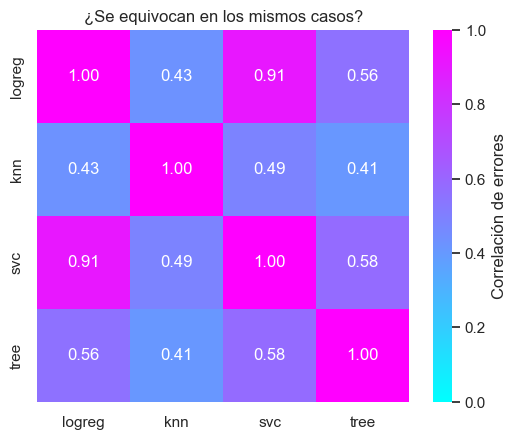

In [8]:
corr_errores = errores.corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr_errores, annot=True, fmt=".2f", cmap="cool", vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Correlación de errores"}, ax=ax)
ax.set_title("¿Se equivocan en los mismos casos?")
plt.tight_layout()
plt.show()

El gráfico dice mucho:

- **Regresión logística y SVC tienen correlación de errores ≈ 0.91**. No es
  casualidad: el mejor SVC que encontró la búsqueda de hiperparámetros fue de **kernel
  lineal**, así que son dos fronteras lineales muy parecidas. A los efectos del
  ensamble, es casi como tener el mismo modelo dos veces (y contando dos votos).
- El **k-NN** es el más independiente de todos (correlación ≈ 0.41–0.49 con el resto):
  al ser un modelo puramente local, se equivoca en otro lado. Es el peor modelo
  individual, pero el que más *diversidad* aporta. Ese es justamente el motivo por el
  que puede convenir mantenerlo en el ensamble a pesar de su F1 bajo.
- El **árbol** queda en el medio (≈ 0.56–0.58 con los lineales): aporta algo de
  diversidad, aunque menos que el k-NN.

Conclusión anticipada: tenemos dos modelos casi redundantes (logística y SVC) y dos
que aportan diversidad pero son más débiles. **No esperemos un salto enorme.** Ahora
midámoslo.

---
## Hard voting

El **voto duro** es la versión más simple: cada modelo emite su clase predicha y gana
la mayoría. En Scikit-Learn lo hacemos con
[`VotingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html)
con `voting='hard'`.

> Con 4 modelos puede haber empates (2 vs 2). Scikit-Learn los resuelve eligiendo la
> clase con el índice más bajo (acá, "no diabetes"), lo que sesga el ensamble hacia la
> clase mayoritaria. Es una razón concreta para preferir un número **impar** de
> votantes, o directamente el voto blando.

In [9]:
hard_voting = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)

metricas_hard = evaluar("Hard voting", hard_voting)
pd.DataFrame([*metricas_base, metricas_hard]).set_index("modelo").round(4)

,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,
Regresión Logística,0.6561,0.7273,0.7921,0.6842,0.7761,0.8707
k-NN,0.5323,0.6230,0.7156,0.6909,0.5672,0.7747
SVC,0.6590,0.7092,0.7771,0.6757,0.7463,0.8633
Árbol,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Hard voting,0.6522,0.7246,0.7891,0.7042,0.7463,NaN


---
## Soft voting

El **voto blando** promedia las *probabilidades* en lugar de las clases. Es
generalmente mejor que el voto duro porque usa más información: un modelo que predice
la clase 1 con probabilidad 0.51 y otro que la predice con 0.99 no están diciendo lo
mismo, y el voto duro no distingue esa diferencia.

Requiere que todos los modelos tengan `predict_proba()` (por eso el SVC lleva
`probability=True`).

In [10]:
soft_voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

metricas_soft = evaluar("Soft voting", soft_voting)
pd.DataFrame([*metricas_base, metricas_hard, metricas_soft]).set_index(
    "modelo").round(4)

,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,
Regresión Logística,0.6561,0.7273,0.7921,0.6842,0.7761,0.8707
k-NN,0.5323,0.6230,0.7156,0.6909,0.5672,0.7747
SVC,0.6590,0.7092,0.7771,0.6757,0.7463,0.8633
Árbol,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Hard voting,0.6522,0.7246,0.7891,0.7042,0.7463,NaN
Soft voting,0.6569,0.6815,0.7553,0.6765,0.6866,0.8652


También podemos **ponderar** los votos, dándole más peso a los modelos que
confiamos más. Como vimos que la logística y el SVC son casi redundantes y el k-NN es
el más débil, probemos bajarle el peso al k-NN.

> Estos pesos son un hiper-parámetro más: en un caso real habría que buscarlos por
> validación cruzada, no elegirlos a ojo.

In [11]:
soft_voting_w = VotingClassifier(estimators=estimators, voting='soft',
                                 weights=[2, 1, 2, 2], n_jobs=-1)

metricas_soft_w = evaluar("Soft voting (ponderado)", soft_voting_w)
pd.DataFrame([*metricas_base, metricas_hard, metricas_soft,
              metricas_soft_w]).set_index("modelo").round(4)

,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,
Regresión Logística,0.6561,0.7273,0.7921,0.6842,0.7761,0.8707
k-NN,0.5323,0.6230,0.7156,0.6909,0.5672,0.7747
SVC,0.6590,0.7092,0.7771,0.6757,0.7463,0.8633
Árbol,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Hard voting,0.6522,0.7246,0.7891,0.7042,0.7463,NaN
Soft voting,0.6569,0.6815,0.7553,0.6765,0.6866,0.8652
Soft voting (ponderado),0.6778,0.6857,0.7582,0.6575,0.7164,0.8654


---
## Stacking

En lugar de fijar *a mano* cómo se combinan los modelos (un voto por cabeza, o pesos
elegidos por nosotros), el **stacking** deja que un segundo modelo —el
*meta-modelo*— **aprenda** la mejor forma de combinarlos. Las predicciones de los
modelos base pasan a ser los atributos de entrada del meta-modelo.

La pregunta clave es: ¿con qué datos entrenamos al meta-modelo? Si usáramos las
predicciones de los modelos base **sobre el mismo train con el que se entrenaron**,
esas predicciones serían optimistas (los modelos ya vieron esos datos, y un árbol
profundo las acertaría todas). El meta-modelo aprendería a confiar en un rendimiento
que no existe fuera del entrenamiento.

La solución es entrenar al meta-modelo con predicciones **out-of-fold**: exactamente
las mismas que calculamos arriba para medir diversidad. Cada predicción viene de un
modelo que *no* vio esa muestra. `StackingClassifier` hace esto internamente a través
del argumento `cv`.

Como meta-modelo usamos una regresión logística: es lo habitual, porque queremos que la
combinación sea simple y no vuelva a sobreajustar.

In [12]:
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=5000),
    cv=CV,
    n_jobs=-1,
)

metricas_stack = evaluar("Stacking", stacking)
df_ens = pd.DataFrame([*metricas_base, metricas_hard, metricas_soft,
                       metricas_soft_w, metricas_stack]).set_index("modelo")
df_ens.round(4)

,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,
Regresión Logística,0.6561,0.7273,0.7921,0.6842,0.7761,0.8707
k-NN,0.5323,0.6230,0.7156,0.6909,0.5672,0.7747
SVC,0.6590,0.7092,0.7771,0.6757,0.7463,0.8633
Árbol,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Hard voting,0.6522,0.7246,0.7891,0.7042,0.7463,NaN
Soft voting,0.6569,0.6815,0.7553,0.6765,0.6866,0.8652
Soft voting (ponderado),0.6778,0.6857,0.7582,0.6575,0.7164,0.8654
Stacking,0.6769,0.7075,0.7761,0.6500,0.7761,0.8683


Podemos mirar **qué aprendió** el meta-modelo: sus coeficientes nos dicen cuánto
pesa cada modelo base en la decisión final.

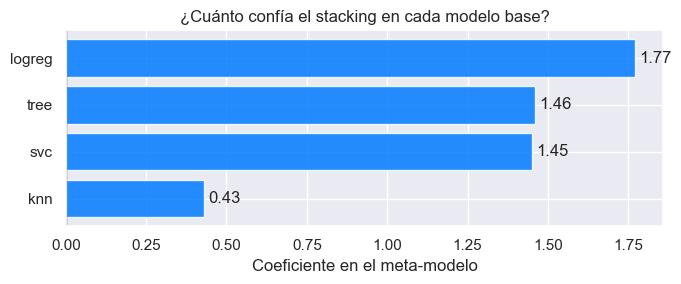

In [13]:
coefs = pd.Series(
    stacking.final_estimator_.coef_[0],
    index=[nombre for nombre, _ in estimators],
).sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
colores = ["#ff48fd" if v < 0 else "#007aff" for v in coefs]
barras = ax.barh(coefs.index, coefs.values, color=colores, alpha=0.85)
ax.bar_label(barras, fmt="%.2f", padding=3)
ax.axvline(0, color="#555555", linewidth=1)
ax.set_xlabel("Coeficiente en el meta-modelo")
ax.set_title("¿Cuánto confía el stacking en cada modelo base?")
plt.tight_layout()
plt.show()

Lo que aprendió el meta-modelo es razonable: le da el **mayor peso a la regresión
logística** (el mejor modelo individual) y **castiga fuertemente al k-NN**, con un
coeficiente unas cuatro veces menor que el resto. Es decir, descubrió por su cuenta
—sin que se lo digamos— cuál de los cuatro modelos aporta menos, algo que en el voting
tuvimos que decidir a mano al elegir los pesos.

Pero también conviene ver **lo que no hizo**: al SVC le asigna un peso casi igual que
al árbol, pese a que sabemos que es redundante con la logística. Un meta-modelo lineal
con dos entradas muy correlacionadas tiende a repartir el peso entre ambas en lugar de
anular una; para que penalice la redundancia habría que regularizarlo más fuerte (bajar
el `C` de la logística final). El stacking ayuda, pero **no es un sustituto de elegir
bien los modelos base**.

---
## Ajuste del umbral (y cómo *no* hacerlo)

Todos estos modelos deciden con el umbral por defecto de 0.5: si la probabilidad
predicha supera 0.5, predicen diabetes. Pero 0.5 no tiene nada de especial, y menos con
clases desbalanceadas. Moviendo el umbral podemos cambiar el balance entre precisión y
recall, y mejorar el F1.

> ⚠️ **El error que hay que evitar.** Es tentador probar muchos umbrales sobre el
> conjunto de **testeo** y quedarse con el que da mejor F1. Eso está mal: el test
> dejaría de ser una estimación honesta del rendimiento, porque lo habríamos usado
> para tomar una decisión de modelado. El número que reportemos sería optimista y no
> se sostendría con datos nuevos.
>
> El umbral es **un hiper-parámetro más** y se elige como cualquier otro: por
> validación cruzada **sobre el entrenamiento**. Recién después se aplica, ya fijo, al
> test.

Hagámoslo bien: buscamos el umbral que maximiza el F1 sobre las predicciones
out-of-fold del entrenamiento.

In [14]:
def buscar_umbral(modelo):
    """Busca el umbral que maximiza el F1 por CV sobre el ENTRENAMIENTO.

    Devuelve el mejor umbral, el F1 de CV que consigue con ese umbral, y las
    curvas completas para poder graficarlas.
    """
    proba_oof = cross_val_predict(modelo, X_train, y_train, cv=CV,
                                  method='predict_proba', n_jobs=-1)[:, 1]
    umbrales = np.linspace(0.05, 0.95, 181)
    f1s = np.array([f1_score(y_train, (proba_oof >= u).astype(int))
                    for u in umbrales])
    return umbrales[f1s.argmax()], f1s.max(), f1s, umbrales


umbral_stack, f1cv_stack, f1s_stack, umbrales = buscar_umbral(stacking)
print(f"Umbral óptimo del stacking (elegido por CV en train): {umbral_stack:.3f}")
print(f"F1 de CV con ese umbral: {f1cv_stack:.4f} "
      f"(contra {metricas_stack['F1 (CV train)']:.4f} con el umbral 0.5)")

Umbral óptimo del stacking (elegido por CV en train): 0.470
F1 de CV con ese umbral: 0.6895 (contra 0.6769 con el umbral 0.5)


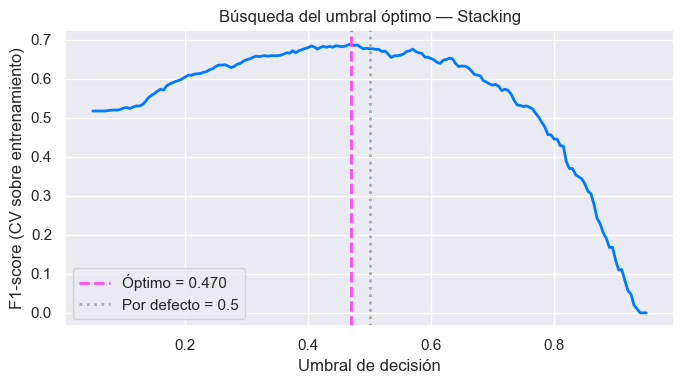

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(umbrales, f1s_stack, color="#007aff", lw=2)
ax.axvline(umbral_stack, color="#ff48fd", linestyle="--", lw=2,
           label=f"Óptimo = {umbral_stack:.3f}")
ax.axvline(0.5, color="#aaaaaa", linestyle=":", lw=2, label="Por defecto = 0.5")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("F1-score (CV sobre entrenamiento)")
ax.set_title("Búsqueda del umbral óptimo — Stacking")
ax.legend()
plt.tight_layout()
plt.show()

Ahora aplicamos el mismo procedimiento a todos los modelos con salida
probabilística y evaluamos, con el umbral ya fijado, sobre el test.

In [16]:
modelos_prob = [
    ("Regresión Logística", logreg),
    ("k-NN", knn),
    ("SVC", svc),
    ("Árbol", tree),
    ("Soft voting", soft_voting),
    ("Soft voting (ponderado)", soft_voting_w),
    ("Stacking", stacking),
]

filas, umbrales_opt = [], {}
for nombre, modelo in modelos_prob:
    u, f1cv, _, _ = buscar_umbral(modelo)
    umbrales_opt[nombre] = u
    filas.append(evaluar(nombre, modelo, umbral=u, f1_cv=f1cv))

df_umbral = pd.DataFrame(filas).set_index("modelo")
df_umbral.insert(0, "Umbral", [umbrales_opt[i] for i in df_umbral.index])  # type: ignore
df_umbral.round(4)

,Umbral,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,,
Regresión Logística,0.410,0.6748,0.7261,0.7934,0.6333,0.8507,0.8707
k-NN,0.050,0.6250,0.6400,0.7099,0.5185,0.8358,0.7747
SVC,0.280,0.6829,0.7342,0.8008,0.6374,0.8657,0.8633
Árbol,0.455,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Soft voting,0.400,0.6894,0.7067,0.7755,0.6386,0.7910,0.8652
Soft voting (ponderado),0.410,0.6879,0.7237,0.7904,0.6471,0.8209,0.8654
Stacking,0.470,0.6895,0.7285,0.7944,0.6548,0.8209,0.8683


Acá aparece el resultado más interesante de la notebook, y hay que leerlo con
cuidado, porque **las dos columnas de F1 cuentan historias distintas**:

- En **F1 por validación cruzada** —que es la métrica con la que *elegimos* modelos, y
  que se calcula sobre las 576 muestras de entrenamiento— los tres ensambles ocupan
  **los tres primeros puestos**: stacking (0.6895), soft voting (0.6894) y soft voting
  ponderado (0.6879) quedan por encima de todos los modelos individuales, incluidos el
  SVC (0.6829) y la regresión logística (0.6748). La mejora es de ~0.01–0.015: chica,
  pero consistente y en la dirección esperada.
- En **F1 de testeo**, en cambio, el ranking se mezcla: gana el SVC (0.7342), con el
  stacking (0.7285), la logística (0.7261) y el hard voting (0.7246) pegados atrás. El
  conjunto de testeo tiene apenas **192 muestras**, así que una diferencia de 0.01 en
  F1 equivale a **un solo paciente** clasificado distinto. Está enteramente dentro del
  ruido.

Esto no es una contradicción, es una lección sobre el tamaño de los datos: la mejora
del ensamble es **real pero pequeña**, y un test chico no tiene resolución suficiente
para medirla. Es exactamente lo que anticipaba la matriz de correlación de errores.

Veamos las curvas ROC, que no dependen del umbral elegido:

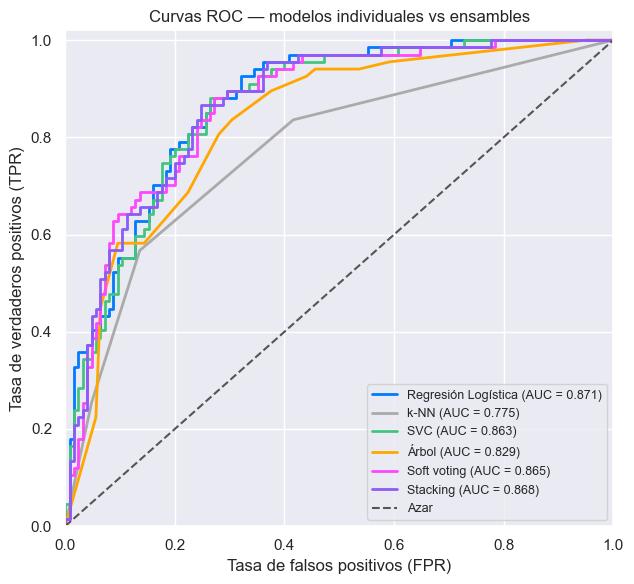

In [17]:
from sklearn.metrics import roc_curve

curvas = [
    ("Regresión Logística", logreg, "#007aff"),
    ("k-NN", knn, "#aaaaaa"),
    ("SVC", svc, "#44c57f"),
    ("Árbol", tree, "#ffa600"),
    ("Soft voting", soft_voting, "#ff48fd"),
    ("Stacking", stacking, "#8b5cf6"),
]

fig, ax = plt.subplots(figsize=(6.5, 6))
for nombre, modelo, color in curvas:
    proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{nombre} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], color="#555555", lw=1.5, linestyle="--", label="Azar")
ax.set_xlim((0, 1))
ax.set_ylim((0, 1.02))
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("Curvas ROC — modelos individuales vs ensambles")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## Comparativa final

Reunimos **todos** los modelos entrenados sobre Pima, con el mismo
split (`test_size=0.25`, `random_state=0`, `stratify=y`), incluyendo la heurística de
referencia:

- **Baseline (umbral de glucosa)** — regla heurística derivada del EDA de la clase 2:
  `glucosa` es el predictor más discriminativo, y el umbral es el punto medio entre la
  mediana de cada clase. No requiere entrenamiento y es el piso contra el que hay que
  comparar todo.
- **k-NN** — el mejor k-NN, encontrado con Optuna.
- **Regresión Logística** — modelo lineal con `class_weight='balanced'`.
- **SVC** — kernel lineal con `class_weight='balanced'`, el mejor de la
  grilla.
- **Árbol de clasificación** — optimizado con Optuna.
- **Hard voting, Soft voting y Stacking** — los ensambles de esta notebook.

Los ensambles y los modelos individuales van con su **umbral óptimo elegido por CV**;
el hard voting no tiene salida probabilística (va con voto de mayoría) y el baseline no
tiene umbral que ajustar.

> Para el baseline, la columna *F1 (CV train)* es directamente el F1 sobre el
> entrenamiento: como no hay nada que entrenar, no hace falta validación cruzada.

In [18]:
# --- Baseline heurístico: umbral de glucosa ---
glucosa_sin = df_pima.loc[df_pima["diabetes"] == 0, "glucosa"]
glucosa_con = df_pima.loc[df_pima["diabetes"] == 1, "glucosa"]
umbral_glucosa = (glucosa_sin.median() + glucosa_con.median()) / 2
y_pred_baseline = (X_test["glucosa"] > umbral_glucosa).astype(int).values

print(f"Umbral de glucosa del baseline: {umbral_glucosa}")

fila_baseline = {
    "modelo": "Baseline (umbral glucosa)",
    "F1 (CV train)": f1_score(
        y_train, (X_train["glucosa"] > umbral_glucosa).astype(int)),
    "F1 (test)": f1_score(y_test, y_pred_baseline),
    "Exac. balanceada": balanced_accuracy_score(y_test, y_pred_baseline),
    "Precisión": precision_score(y_test, y_pred_baseline),
    "Recall": recall_score(y_test, y_pred_baseline),
    "AUC": roc_auc_score(y_test, X_test["glucosa"]),
}

Umbral de glucosa del baseline: 123.5


In [19]:
df_final = pd.DataFrame([fila_baseline, *filas, metricas_hard]).set_index("modelo")
df_final = df_final.sort_values("F1 (test)", ascending=False)
df_final.round(4)

,F1 (CV train),F1 (test),Exac. balanceada,Precisión,Recall,AUC
modelo,,,,,,
SVC,0.6829,0.7342,0.8008,0.6374,0.8657,0.8633
Stacking,0.6895,0.7285,0.7944,0.6548,0.8209,0.8683
Regresión Logística,0.6748,0.7261,0.7934,0.6333,0.8507,0.8707
Hard voting,0.6522,0.7246,0.7891,0.7042,0.7463,NaN
Soft voting (ponderado),0.6879,0.7237,0.7904,0.6471,0.8209,0.8654
Soft voting,0.6894,0.7067,0.7755,0.6386,0.7910,0.8652
Árbol,0.6681,0.6957,0.7659,0.5957,0.8358,0.8294
Baseline (umbral glucosa),0.6318,0.6533,0.7297,0.5904,0.7313,0.8132
k-NN,0.6250,0.6400,0.7099,0.5185,0.8358,0.7747


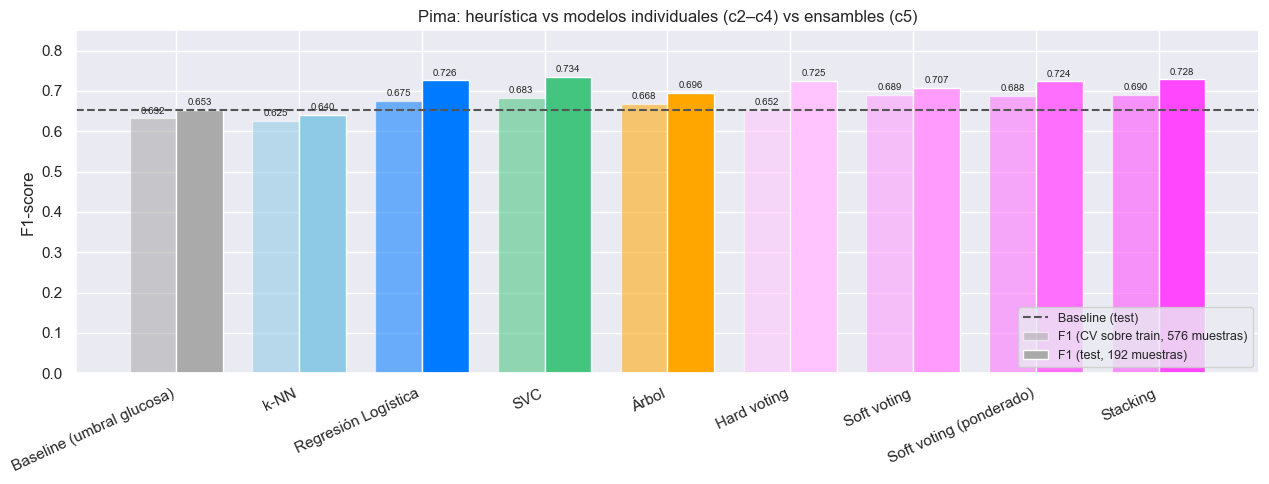

In [20]:
orden = ["Baseline (umbral glucosa)", "k-NN", "Regresión Logística",
         "SVC", "Árbol", "Hard voting", "Soft voting",
         "Soft voting (ponderado)", "Stacking"]
colores = ["#aaaaaa", "#8ecae6", "#007aff", "#44c57f", "#ffa600",
           "#ffc4fe", "#ff9bfd", "#ff6ffd", "#ff48fd"]

df_plot = df_final.loc[orden, ["F1 (CV train)", "F1 (test)"]]
x = np.arange(len(orden))
ancho = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - ancho / 2, df_plot["F1 (CV train)"], ancho,
            label="F1 (CV sobre train, 576 muestras)", color=colores,
            alpha=0.55, edgecolor="white")
b2 = ax.bar(x + ancho / 2, df_plot["F1 (test)"], ancho,
            label="F1 (test, 192 muestras)", color=colores, alpha=1.0,
            edgecolor="white")
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=7)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=7)

ax.axhline(df_final.loc["Baseline (umbral glucosa)", "F1 (test)"],
           color="#555555", linestyle="--", lw=1.5, label="Baseline (test)")
ax.set_xticks(x)
ax.set_xticklabels(orden, rotation=25, ha="right")
ax.set_ylabel("F1-score")
ax.set_ylim(0, 0.85)
ax.set_title("Pima: heurística vs modelos individuales (c2–c4) vs ensambles (c5)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### Observaciones

- **En F1 de validación cruzada, los ensambles ganan:** los tres primeros puestos son
  stacking, soft voting y soft voting ponderado, por encima del SVC y de la regresión
  logística, que venía siendo la campeona. La mejora es de ~0.01–0.015:
  chica, pero **consistente** y medida sobre 576 muestras.
- **En F1 de testeo el ranking se mezcla y las diferencias se vuelven ruido.** Ahí gana
  el SVC por 0.006 sobre el stacking. Con 192 muestras de test, un solo paciente
  clasificado distinto alcanza para reordenar la tabla. Es una advertencia práctica
  importante: no hay que declarar ganadores por diferencias de la tercera cifra decimal
  en un test chico, y conviene mirar siempre las dos columnas juntas.
- **La matriz de correlación de errores lo había anticipado.** Con logística y SVC
  fuertemente correlacionados, el ensamble tenía poco margen: le sobra un modelo
  redundante y le falta diversidad real. Medir la diversidad **antes** de ensamblar nos
  ahorró la sorpresa.
- **El baseline de glucosa sigue siendo sorprendentemente digno** (F1 ≈ 0.65) para ser
  una sola regla sin entrenamiento. Todos los modelos le ganan, pero el margen del
  mejor ensamble sobre una única línea de código es de apenas 0.07 en F1. Es el
  recordatorio de siempre: sin un baseline honesto no se sabe cuánto se está aportando.
- **En validación cruzada, el voto blando le gana al duro** (0.689 vs 0.652), como era
  de esperar: promediar probabilidades usa más información que contar votos, y evita el
  problema de los empates con un número par de votantes. En test la relación se
  invierte, lo cual —otra vez— entra dentro del margen de ruido de 192 muestras.

### Entonces, ¿sirve el ensamble heterogéneo?

Sirve, pero acá está limitado por el material con el que trabaja: cuatro modelos de los
cuales dos son casi el mismo, sobre un dataset chico con señal esencialmente lineal.
El ensamble no puede inventar diversidad que no existe.

La pregunta natural es: **¿y si en vez de esperar que los modelos sean diversos,
construimos diversidad a propósito?** Esa es exactamente la idea de bagging, random
forest y boosting, y es lo que vemos en las próximas notebooks.